预测一个太空飞船在发生碰撞时候，乘客是否会发送到另一个维度

提交记录
- randomforest: 0.72

## 数据认识

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
pd.__version__

'2.3.3'

In [68]:
train_data = pd.read_csv('data/train.csv')
train_data.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [69]:
train_data.shape

(8693, 14)

In [70]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [71]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


# 数据分析

## 列分类

In [72]:
# 拆分列
train_data[['Deck','CabinNum', 'Side']] = train_data['Cabin'].str.split('/', expand=True)

In [45]:
# 统计缺失值
train_data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Deck            199
CabinNum        199
Side            199
dtype: int64

In [73]:
# drop column:  name,cabin,passengerId
train_data = train_data.drop(columns=['PassengerId', 'Name', 'Cabin'])
numerical_columns = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
target_column = 'Transported'
categorical_columns =  ['HomePlanet', 'CryoSleep', 'Destination', 'VIP','Deck','CabinNum', 'Side']
print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categorical columns: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'CabinNum', 'Side']


In [47]:
train_data[numerical_columns].describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [74]:
from sklearn.model_selection import train_test_split
X = train_data[numerical_columns + categorical_columns]
y = train_data[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (6954, 13)
Test set shape: (1739, 13)


## target column 分析

In [48]:
train_data[target_column].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Transported')

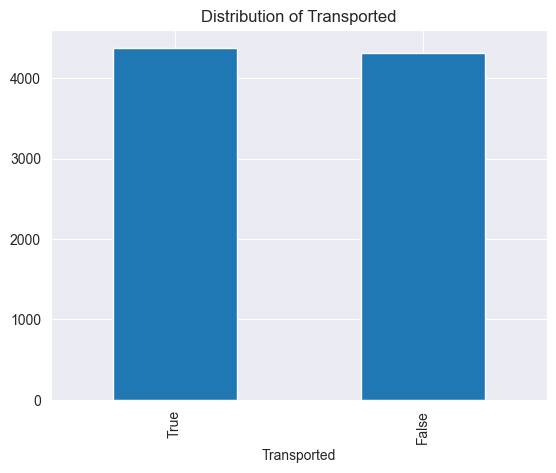

In [49]:
train_data['Transported'].value_counts().plot(kind='bar')
plt.title('Distribution of Transported')

In [50]:
train_data[target_column] = train_data[target_column].astype(int)

可以看到，目标列的值分布均匀。

## numerical column 分析

In [51]:
numerical_columns

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

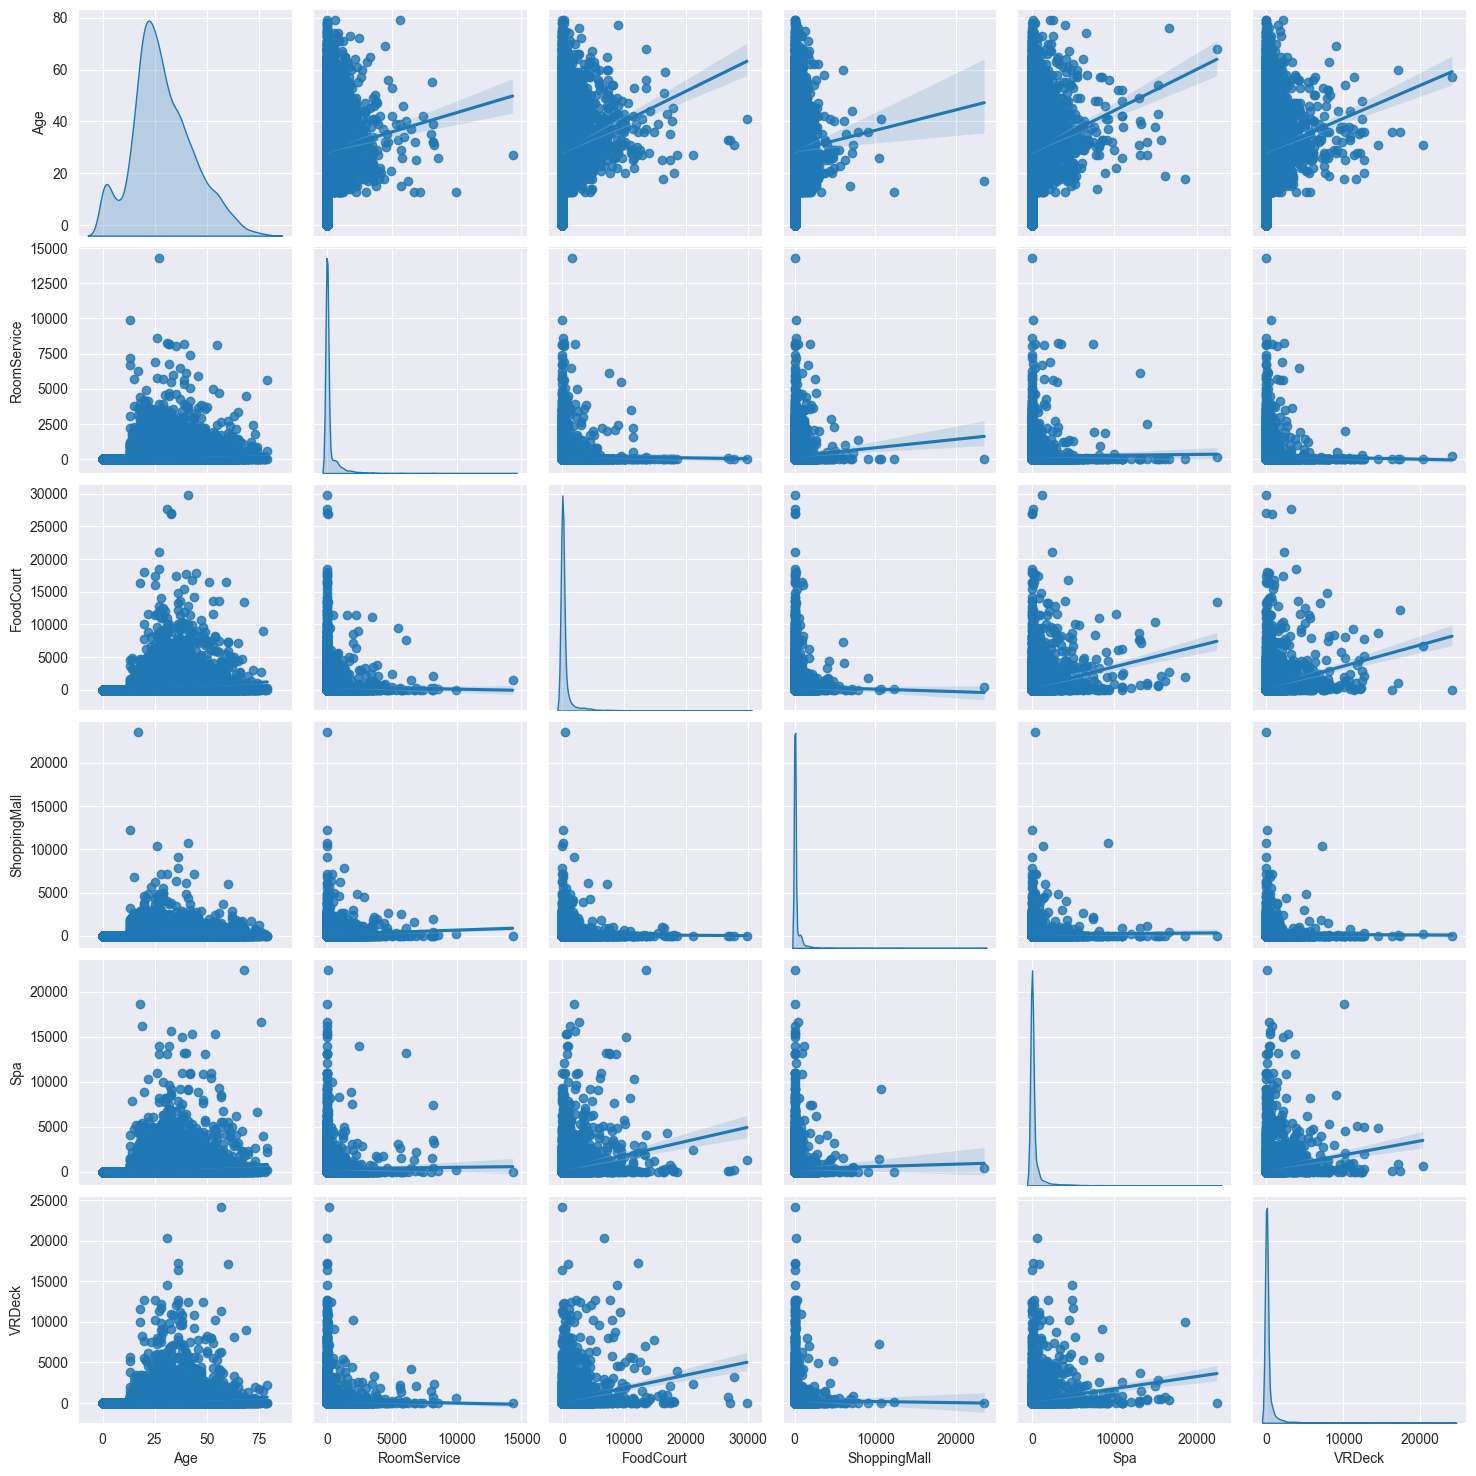

In [52]:
sns.pairplot(train_data[numerical_columns], kind='reg', diag_kind='kde')

- age呈现双峰正太分布
- 这几个属性之间没什么相关关系。

### age清洗

<Axes: xlabel='Age', ylabel='Count'>

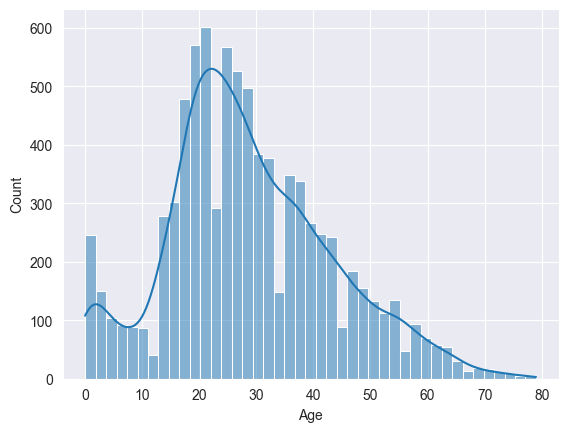

In [53]:
sns.histplot(train_data['Age'], kde=True)

都是合理的，不应该去掉age=0的那些，可能是婴儿把。

In [54]:
train_data['Age'][train_data['Age'].isna()]

50     NaN
64     NaN
137    NaN
181    NaN
184    NaN
        ..
8274   NaN
8301   NaN
8374   NaN
8407   NaN
8557   NaN
Name: Age, Length: 179, dtype: float64

In [55]:
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)

C:\Users\63517\AppData\Local\Temp\ipykernel_24204\892819329.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)


In [56]:
train_data['Age'] = train_data['Age'].astype(int)

<Axes: xlabel='Age', ylabel='Count'>

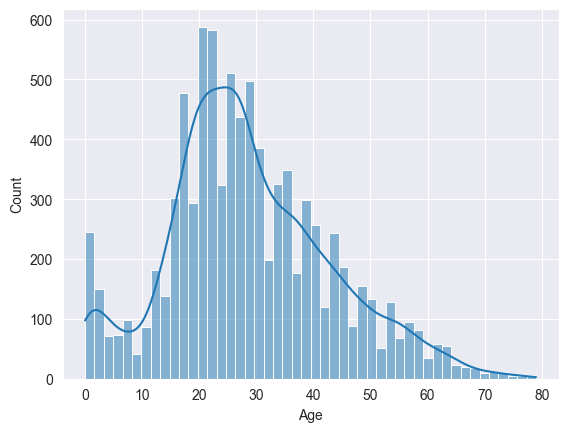

In [57]:
sns.histplot(train_data['Age'], kde=True)

age列处理完毕， 保持分布

### 其他列清洗

<Axes: ylabel='RoomService'>

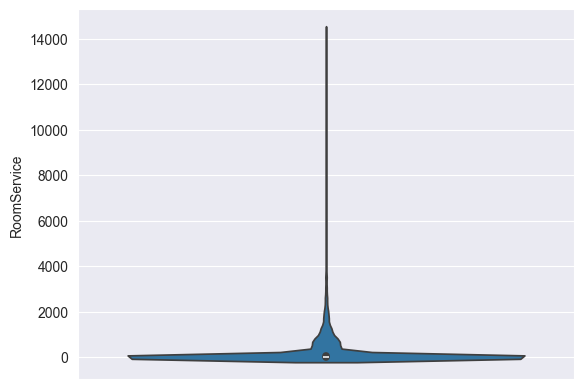

In [58]:
sns.violinplot(train_data['RoomService'])

In [59]:
train_data[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = train_data[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)

## categorical column 分析

In [60]:
train_data[categorical_columns].isnull().sum()

HomePlanet     201
CryoSleep      217
Destination    182
VIP            203
Deck           199
CabinNum       199
Side           199
dtype: int64

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 60851 stored elements and shape (8693, 1844)>

# 数据预处理

In [80]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore',), categorical_columns)
    ]
)


# 模型

## 随机森林

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [82]:
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [83]:
accuracy = clf.score(X_test, y_test)
print(f"Model accuracy on test set: {accuracy:.2%}")
print(f"accuracy on train set: {clf.score(X_train, y_train):.2%}")

Model accuracy on test set: 72.00%
accuracy on train set: 97.57%


## 提交

In [89]:
test = pd.read_csv('data/test.csv')
test[['Deck','CabinNum', 'Side']] = test['Cabin'].str.split('/', expand=True)
test['Transported'] = clf.predict(test[numerical_columns + categorical_columns])
test[['PassengerId', 'Transported']].to_csv('data/submission.csv', index=False)